# Tarea 8 — Clustering de vinos: K-Means y clustering jerárquico
**Lead University · Minería de Datos · Tarea 8**

Clustering de `wine-clustering.csv` (Kaggle: *Wine Clustering*, derivado del clásico UCI Wine):
178 muestras de vino descritas por 13 propiedades fisicoquímicas, todas numéricas y continuas.

**Objetivo:** determinar el número óptimo de clusters con el Codo de Jambú, aplicar K-Means y
clustering jerárquico aglomerativo, y comparar ambas particiones sobre el plano del PCA. El dataset
original proviene de tres cultivares italianos, pero la columna de clase no viene incluida en el
archivo, tal como corresponde a un problema de aprendizaje no supervisado.

---
## a) Selección y exploración de datos

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.preprocessing import StandardScaler

from scripts import ClusteringJerarquico, KMeansAnalysis

warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 30)
np.set_printoptions(threshold=60, suppress=True)
sns.set_theme(style="whitegrid")

In [2]:
datos = pd.read_csv("datos/wine-clustering.csv")
print("Dimensiones:", datos.shape)
datos.head()

Dimensiones: (178, 13)


,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [4]:
variables = list(datos.columns)
datos.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.00,0.81,11.03,12.36,13.05,13.68,14.83
Malic_Acid,178.0,2.34,1.12,0.74,1.60,1.87,3.08,5.80
Ash,178.0,2.37,0.27,1.36,2.21,2.36,2.56,3.23
Ash_Alcanity,178.0,19.49,3.34,10.60,17.20,19.50,21.50,30.00
Magnesium,178.0,99.74,14.28,70.00,88.00,98.00,107.00,162.00
Total_Phenols,178.0,2.30,0.63,0.98,1.74,2.36,2.80,3.88
Flavanoids,178.0,2.03,1.00,0.34,1.20,2.13,2.88,5.08
Nonflavanoid_Phenols,178.0,0.36,0.12,0.13,0.27,0.34,0.44,0.66
Proanthocyanins,178.0,1.59,0.57,0.41,1.25,1.56,1.95,3.58
Color_Intensity,178.0,5.06,2.32,1.28,3.22,4.69,6.20,13.00


**Contexto del dataset:**
El dataset trae 178 muestras y 13 variables, todas numéricas y continuas: no hay columnas categóricas ni
identificadores, cada fila es una muestra de vino caracterizada íntegramente por su composición
fisicoquímica, lo que lo vuelve el caso ideal para un clustering basado en distancias. Los estadísticos
descriptivos muestran una disparidad de escalas incluso más severa que en el dataset de clientes:
`Proline` va de 278 a 1 680, `Magnesium` de 70 a 162 y `Nonflavanoid_Phenols` de 0,13 a 0,66. Sin
estandarizar, `Proline` aportaría por sí sola más del 99 % de la distancia euclídea y las otras doce
variables serían invisibles para el algoritmo. A diferencia del dataset de clientes, aquí las
desviaciones estándar son grandes en relación con los rangos en variables como `Flavanoids` o
`Color_Intensity`, lo que sugiere la presencia de subpoblaciones con valores muy distintos.

In [5]:
print("Valores nulos por columna:")
print(datos.isna().sum())
print("\nTotal de nulos:", int(datos.isna().sum().sum()))
print("Filas duplicadas:", int(datos.duplicated().sum()))

Valores nulos por columna:
Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

Total de nulos: 0
Filas duplicadas: 0


**Calidad de los datos:**
El dataset está completamente limpio: cero nulos y cero filas duplicadas en las 178 muestras. Es lo
esperable en datos de laboratorio, donde cada valor proviene de una medición analítica controlada y no
de un formulario. Tampoco hay ceros sospechosos, porque ninguna de las 13 variables puede valer cero de
forma legítima en un vino y ninguna lo hace, así que no se requiere ninguna imputación.

---
## b) Preprocesamiento

In [6]:
df = datos.copy()

# Detección de atípicos con la regla del rango intercuartílico (1.5 · IQR)
resumen_atipicos = []
for col in variables:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df[col] < lo) | (df[col] > hi)).sum())
    resumen_atipicos.append({
        "variable": col,
        "limite_inf": round(lo, 2),
        "limite_sup": round(hi, 2),
        "n_atipicos": n_out,
        "%_atipicos": round(n_out / len(df) * 100, 1),
    })

tabla_atipicos = pd.DataFrame(resumen_atipicos)
tabla_atipicos

,variable,limite_inf,limite_sup,n_atipicos,%_atipicos
0,Alcohol,10.39,15.65,0,0.0
1,Malic_Acid,-0.62,5.30,3,1.7
2,Ash,1.69,3.08,3,1.7
3,Ash_Alcanity,10.75,27.95,4,2.2
4,Magnesium,59.50,135.50,4,2.2
5,Total_Phenols,0.16,4.39,0,0.0
6,Flavanoids,-1.30,5.38,0,0.0
7,Nonflavanoid_Phenols,0.02,0.69,0,0.0
8,Proanthocyanins,0.20,3.00,2,1.1
9,Color_Intensity,-1.25,10.67,4,2.2


In [7]:
# ¿Cuántas observaciones son atípicas en valores extremos (|z| > 4)?
z_scores = (df - df.mean()) / df.std()
print("Observaciones con al menos una variable |z| > 3:", int((z_scores.abs() > 3).any(axis=1).sum()))
print("Observaciones con al menos una variable |z| > 4:", int((z_scores.abs() > 4).any(axis=1).sum()))
print("\nCeldas con |z| > 3 por variable:")
print((z_scores.abs() > 3).sum()[lambda s: s > 0])

Observaciones con al menos una variable |z| > 3: 10
Observaciones con al menos una variable |z| > 4: 1

Celdas con |z| > 3 por variable:
Malic_Acid         1
Ash                3
Ash_Alcanity       1
Magnesium          2
Flavanoids         1
Proanthocyanins    1
Color_Intensity    1
Hue                1
dtype: int64


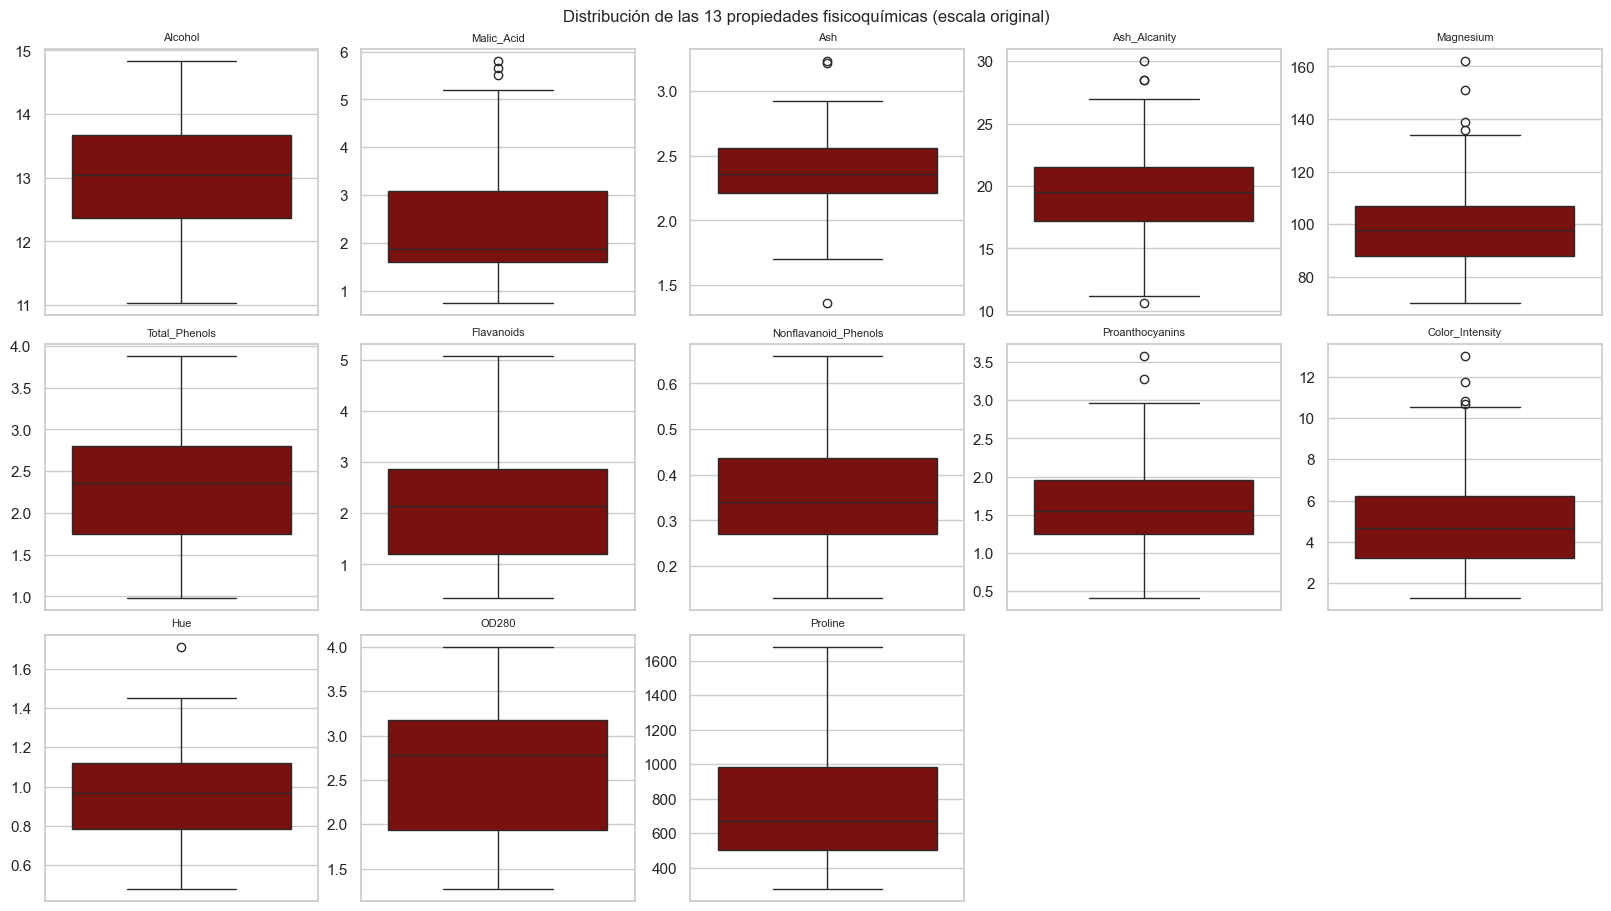

In [8]:
fig, axes = plt.subplots(3, 5, figsize=(16, 9), constrained_layout=True)
for ax, col in zip(axes.ravel(), variables):
    sns.boxplot(y=df[col], ax=ax, color="darkred")
    ax.set_title(col, fontsize=8)
    ax.set_ylabel("")
for j in range(len(variables), 15):
    axes.ravel()[j].set_visible(False)
fig.suptitle("Distribución de las 13 propiedades fisicoquímicas (escala original)", fontsize=12)
plt.show()

**Tratamiento de atípicos:**
La regla del 1,5 · IQR marca 21 celdas atípicas repartidas en 8 variables, ninguna con más del 2,2 % de
las observaciones; las más afectadas son `Ash_Alcanity`, `Magnesium` y `Color_Intensity`, con cuatro
casos cada una. Con el criterio más estricto de |z| > 4 solo queda una observación marcada en todo el
dataset. No se elimina ni recorta ningún atípico, por tres razones de dominio: son mediciones de
laboratorio válidas y no errores de captura, ya que un vino con `Color_Intensity` de 13 es un vino
intensamente coloreado; la variación extrema es precisamente la señal buscada, porque si tres cultivares
producen composiciones químicas distintas los valores en los extremos son los más informativos para
separarlos; y con solo 178 muestras eliminar filas costaría poder estadístico sin ganancia alguna. Los
boxplots confirman el diagnóstico, y en `Flavanoids`, `Total_Phenols` y `OD280` se aprecian cajas
amplias sin atípicos, compatibles con distribuciones bimodales, otra pista de subgrupos reales.

In [9]:
# Estandarización obligatoria (z-score): media 0, desviación 1
escalador = StandardScaler()
X = escalador.fit_transform(df)
X_scaled = pd.DataFrame(X, columns=variables)
X_scaled.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,-0.0,1.003,-2.434,-0.788,0.061,0.836,2.260
Malic_Acid,178.0,-0.0,1.003,-1.433,-0.659,-0.423,0.670,3.109
Ash,178.0,-0.0,1.003,-3.679,-0.572,-0.024,0.698,3.156
Ash_Alcanity,178.0,-0.0,1.003,-2.671,-0.689,0.002,0.602,3.155
Magnesium,178.0,-0.0,1.003,-2.088,-0.824,-0.122,0.510,4.371
Total_Phenols,178.0,0.0,1.003,-2.107,-0.885,0.096,0.809,2.540
Flavanoids,178.0,-0.0,1.003,-1.696,-0.828,0.106,0.849,3.063
Nonflavanoid_Phenols,178.0,0.0,1.003,-1.868,-0.740,-0.176,0.610,2.402
Proanthocyanins,178.0,-0.0,1.003,-2.069,-0.597,-0.063,0.629,3.485
Color_Intensity,178.0,0.0,1.003,-1.634,-0.795,-0.159,0.494,3.435


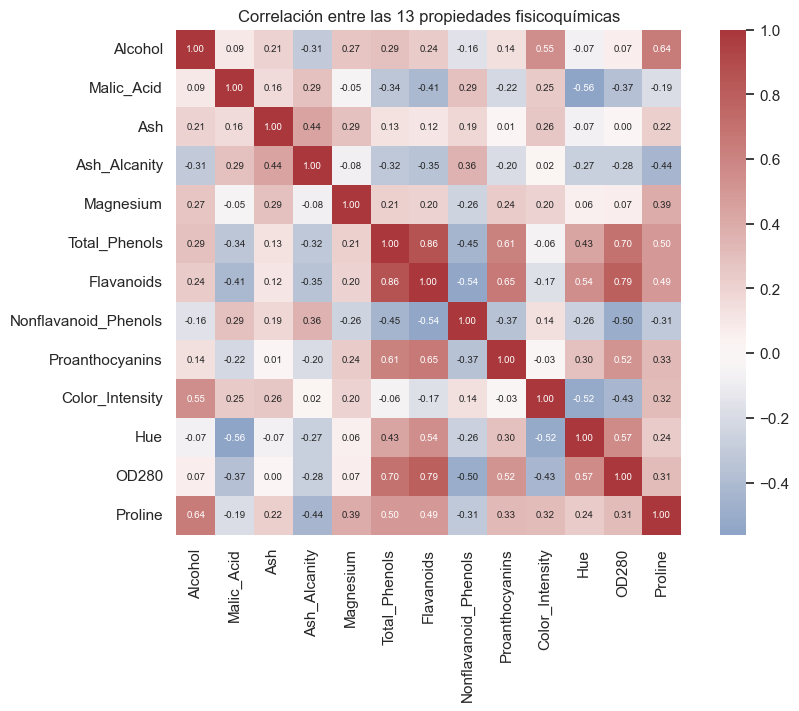

In [10]:
fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax,
            annot_kws={"size": 7}, square=True)
ax.set_title("Correlación entre las 13 propiedades fisicoquímicas")
plt.show()

**Estandarización y estructura de correlaciones:**
Tras el z-score las 13 variables quedan con media 0 y desviación 1: el rango de `Proline` pasa de
278–1 680 a aproximadamente −1,5 a +3,0 y ya pesa lo mismo que cualquier otra propiedad. El mapa de
correlaciones revela una estructura química muy distinta a la del dataset de clientes, donde las
variables eran casi independientes. Aquí hay un bloque fenólico fuerte —`Total_Phenols` con `Flavanoids`
(r = 0,86), `Flavanoids` con `OD280` (r = 0,79), `Total_Phenols` con `OD280` (r = 0,70) y ambos con
`Proanthocyanins` (r cercano a 0,63)— que tiene sentido bioquímico, porque los flavonoides son un
subconjunto de los polifenoles totales y el `OD280` es precisamente una medida espectrofotométrica de
compuestos fenólicos. También destaca `Alcohol` con `Proline` (r = 0,64): la prolina es el aminoácido
más abundante en la uva y su concentración acompaña el grado de madurez, que a su vez determina el
alcohol potencial. Esta redundancia es una buena noticia para el clustering, porque significa que existe
una dirección dominante de variación que el PCA podrá aprovechar.

---
## c) Determinación del número óptimo de clusters (K)

In [11]:
km = KMeansAnalysis(X_scaled)

(178, 13)


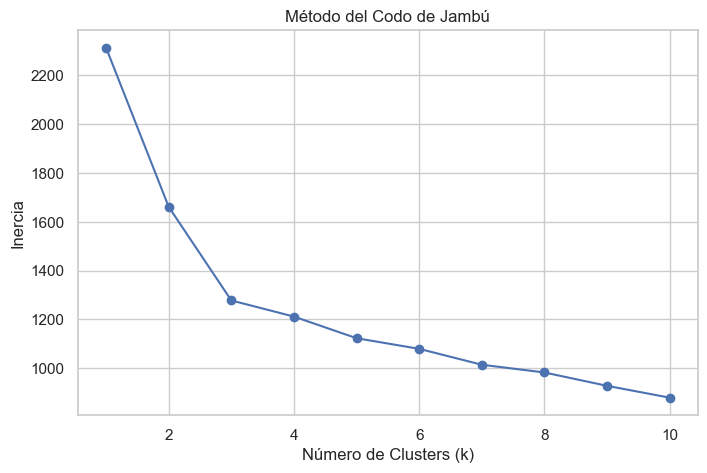

,k,inercia,reduccion_%_vs_k-1
0,2,1661.7,28.2
1,3,1277.9,23.1
2,4,1211.8,5.2
3,5,1123.2,7.3
4,6,1079.5,3.9
5,7,1014.4,6.0
6,8,982.7,3.1
7,9,928.0,5.6
8,10,879.4,5.2


In [12]:
inercias = km.codo_jambu(max_k=10)

caidas = [(inercias[i - 1] - inercias[i]) / inercias[i - 1] * 100 for i in range(1, len(inercias))]
pd.DataFrame({
    "k": range(2, 11),
    "inercia": np.round(inercias[1:], 1),
    "reduccion_%_vs_k-1": np.round(caidas, 1),
})

**Método del Codo de Jambú:**
Aquí sí aparece el codo de libro de texto, y el contraste con el dataset de clientes es notable: la
reducción de inercia es del 28,2 % en k=2 y del 23,1 % en k=3, y cae de golpe al 5,2 % en k=4, para
oscilar después entre 3,1 % y 7,3 % de k=5 a k=10 sin recuperar nunca el nivel previo. El quiebre es
inequívoco y sitúa el codo en K = 3. La serie no es perfectamente monótona —k=5 repunta a 7,3 % y k=7 a
6,0 %— porque con solo 178 observaciones cada partición adicional es sensible a la inicialización, pero
esos repuntes son ruido de magnitud pequeña y ninguno se acerca al 23 % del tercer cluster. Frente al
dataset de clientes, donde la mayor reducción fue de 14,4 % y el descenso era gradual, aquí el algoritmo
está encontrando estructura real, y el resultado coincide además con el conocimiento de dominio, porque
el dataset UCI Wine original proviene de tres cultivares de uva italianos.

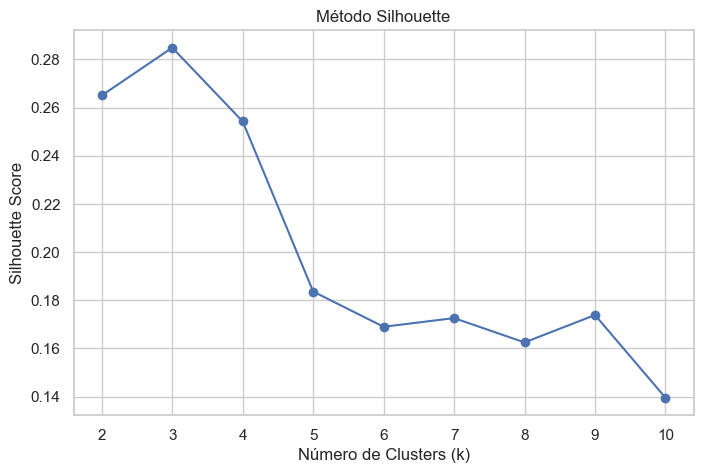

,k,silhouette
0,2,0.2650
1,3,0.2849
2,4,0.2542
3,5,0.1836
4,6,0.1690
5,7,0.1726
6,8,0.1625
7,9,0.1739
8,10,0.1396


In [13]:
sil_df = km.silhouette_kmeans(max_k=10)
sil_df.round(4)

**Método de la Silueta:**
La silueta confirma de forma independiente el valor K = 3: es su máximo global (0,2849) y desde ahí
desciende hasta 0,1396 en k=10. Esta forma de curva, con pico interior claro y descenso posterior, es la
que se espera cuando existen grupos reales, porque pasar de 3 a 4 clusters obliga a partir un grupo
genuino —la silueta cae a 0,2542— y de k=5 en adelante no vuelve a superar 0,18. El contraste con el
dataset de clientes es el hallazgo metodológico central de esta tarea: allí la silueta máxima era de
0,167 en k=9, con una curva plana y creciente que no coincidía con el codo, mientras que aquí hay un pico
definido en el mismo punto que señala el codo.

Aun así hay que ser honestos sobre la magnitud: 0,285 sigue siendo un valor moderado, por debajo del
umbral de 0,5 que indicaría clusters bien separados. La razón es que se trabaja en 13 dimensiones, donde
las distancias euclídeas se concentran por la maldición de la dimensionalidad y la silueta se degrada
aunque los grupos sean reales. La estructura existe y ambos criterios la detectan en el mismo punto;
simplemente no es tan nítida como sugeriría una silueta cercana a 1.

In [14]:
K = 3
print(f"K seleccionado = {K}")
print(f"Silueta en K={K}: {sil_df.loc[sil_df['k'] == K, 'silhouette'].iloc[0]:.4f}  (máximo de la curva)")

K seleccionado = 3
Silueta en K=3: 0.2849  (máximo de la curva)


---
## d) Aplicación de algoritmos

### K-Means con el K óptimo

In [15]:
etiquetas_km, centros_km = km.ajustar(n_clusters=K, random_state=42)

Grupos
 [2 2 2 ... 1 1 1]
Centros
 [[-0.92607185 -0.39404154 -0.49451676  0.17060184 -0.49171185 -0.07598265
   0.02081257 -0.03353357  0.0582655  -0.90191402  0.46180361  0.27076419
  -0.75384618]
 [ 0.16490746  0.87154706  0.18689833  0.52436746 -0.07547277 -0.97933029
  -1.21524764  0.72606354 -0.77970639  0.94153874 -1.16478865 -1.29241163
  -0.40708796]
 [ 0.83523208 -0.30380968  0.36470604 -0.61019129  0.5775868   0.88523736
   0.97781956 -0.56208965  0.58028658  0.17106348  0.47398365  0.77924711
   1.12518529]]


In [16]:
pd.DataFrame(centros_km, columns=variables).round(2).rename_axis("cluster").T

cluster,0,1,2
Alcohol,-0.93,0.16,0.84
Malic_Acid,-0.39,0.87,-0.30
Ash,-0.49,0.19,0.36
Ash_Alcanity,0.17,0.52,-0.61
Magnesium,-0.49,-0.08,0.58
Total_Phenols,-0.08,-0.98,0.89
Flavanoids,0.02,-1.22,0.98
Nonflavanoid_Phenols,-0.03,0.73,-0.56
Proanthocyanins,0.06,-0.78,0.58
Color_Intensity,-0.90,0.94,0.17


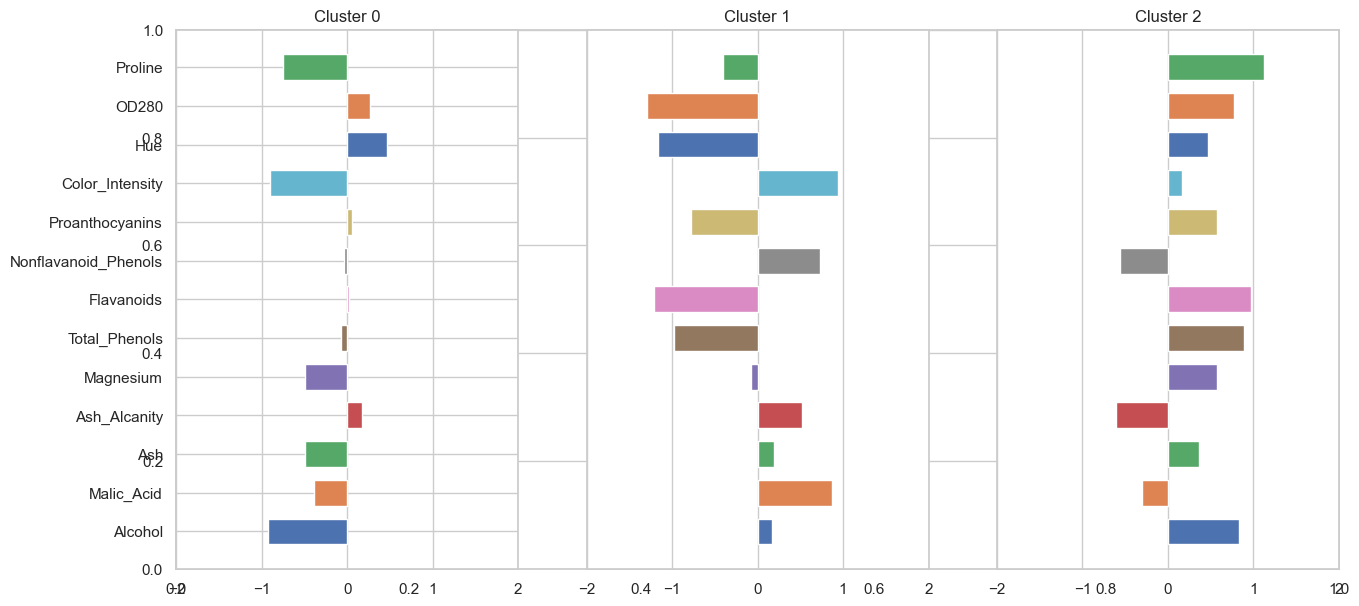

In [17]:
fig = km.plot_barras_centros(figsize=(15, 7))
plt.show()

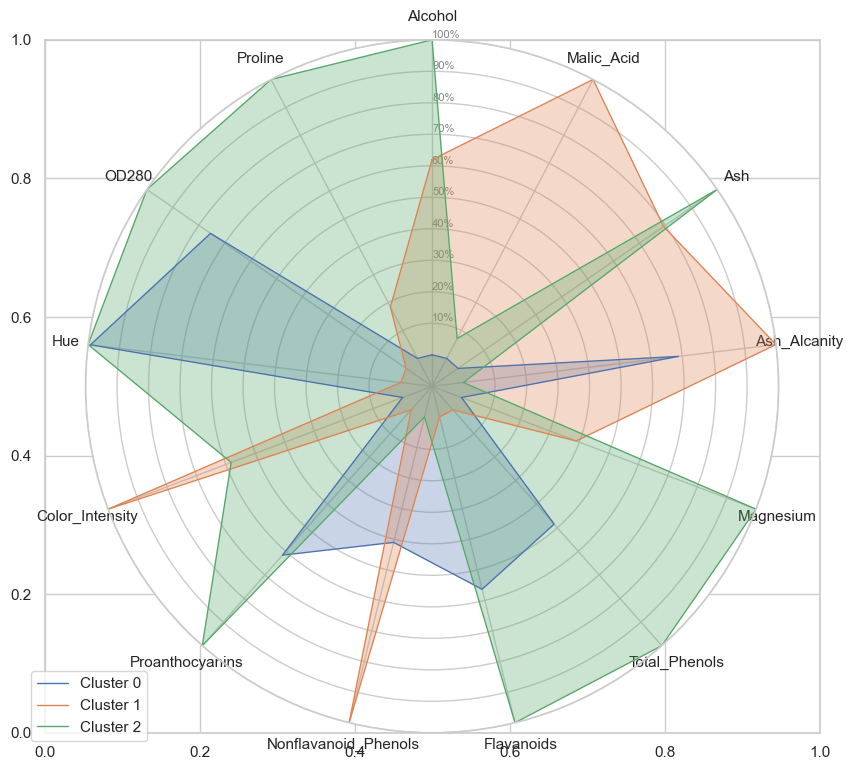

In [18]:
fig = km.plot_radar_centros(figsize=(10, 9))
plt.show()

In [19]:
perfil_km = km.tabla_perfiles(datos_originales=df)
perfil_km.T

cluster,0,1,2
n,65.00,51.00,62.00
Alcohol,12.25,13.13,13.68
Malic_Acid,1.90,3.31,2.00
Ash,2.23,2.42,2.47
Ash_Alcanity,20.06,21.24,17.46
Magnesium,92.74,98.67,107.97
Total_Phenols,2.25,1.68,2.85
Flavanoids,2.05,0.82,3.00
Nonflavanoid_Phenols,0.36,0.45,0.29
Proanthocyanins,1.62,1.15,1.92


**Perfil enológico de los tres clusters:**
A diferencia del dataset de clientes, donde cada grupo se definía por una sola variable, aquí cada
cluster tiene un perfil químico coherente en varias variables a la vez, que es exactamente lo que se
espera de grupos con base física real. El cluster 0 (65 muestras) reúne los vinos ligeros: `Alcohol` en
−0,93 z (12,25 %, el más bajo), `Color_Intensity` en −0,90 z (2,97, el más pálido), `Proline` en −0,75 z
y fenoles en torno a la media; son vinos de graduación baja, color pálido y poca extracción, pero sin
defecto fenólico. El cluster 1 (51 muestras) es el químicamente más extremo: `OD280` en −1,29 z y
`Flavanoids` en −1,22 z (0,82, un tercio del cluster 2), `Hue` en −1,16 z y `Malic_Acid` en +0,87 z,
pero con el color más intenso de todos (+0,94 z, 7,23). Esa combinación de mucho color, pocos
flavonoides y tono apagado es la firma de un cultivar diferenciado. El cluster 2 (62 muestras) reúne los
vinos estructurados: `Proline` en +1,13 z (1 100, más del doble del cluster 0), `Flavanoids` en +0,98 z
(3,00), `Alcohol` en +0,84 z (13,68 %, el más alto) y la alcalinidad de cenizas más baja; son los vinos
con más cuerpo y potencial de guarda.

El radar muestra los tres polígonos ocupando regiones claramente distintas del espacio, en contraste con
el solapamiento que se observaba en el dataset de clientes. Los tamaños (65 / 51 / 62) están
razonablemente equilibrados y son compatibles con la distribución conocida de los tres cultivares del
dataset UCI original (59 / 71 / 48).

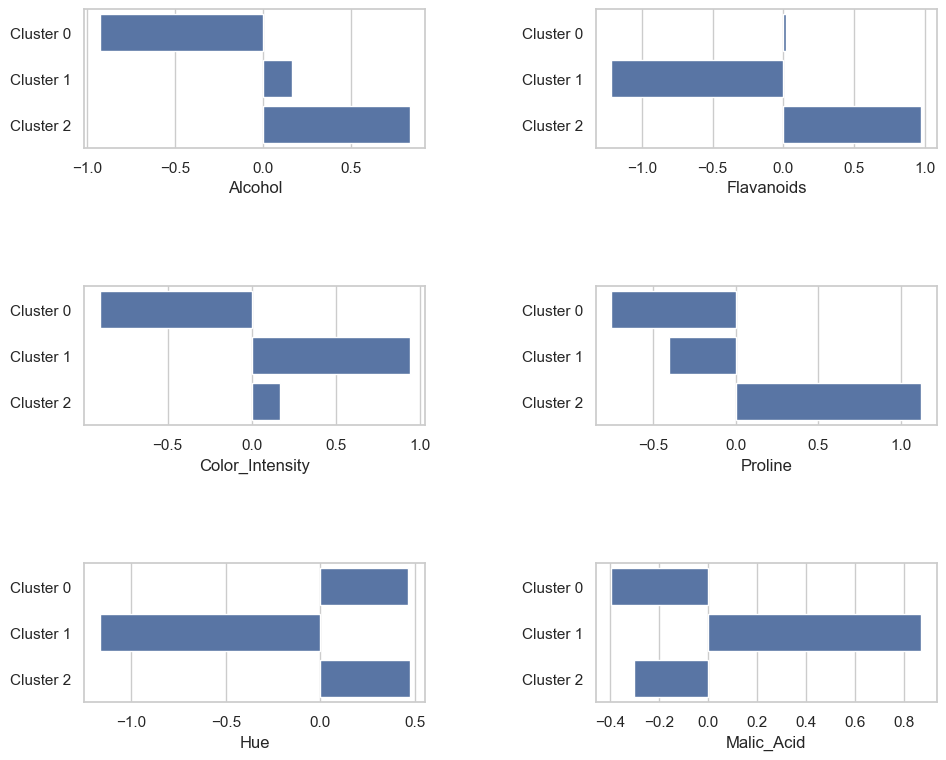

In [20]:
fig = km.plot_detalle_centros(
    columns_to_plot=["Alcohol", "Flavanoids", "Color_Intensity", "Proline", "Hue", "Malic_Acid"],
    figsize=(11, 9),
    dpi=100,
)
plt.show()

**Detalle de las variables más discriminantes:**
Se seleccionaron las seis variables con mayor separación entre centroides. `Flavanoids` es la más
discriminante de todas y separa nítidamente al cluster 1 (0,82) de los otros dos (2,05 y 3,00); por sí
sola casi define un grupo. `Alcohol` y `Proline` ordenan los tres clusters de forma monótona y funcionan
como un eje de cuerpo del vino, mientras que `Color_Intensity` invierte ese orden, porque el cluster 1
es el más intenso pese a no ser el más alcohólico, lo que demuestra que el color no es un simple
derivado del cuerpo. `Hue` y `Malic_Acid` aíslan al cluster 1 en el extremo opuesto de los otros dos. Lo
relevante es que ninguna variable por sí sola separa los tres grupos: hacen falta combinaciones, lo que
justifica el uso de clustering multivariante en lugar de simples cortes univariados.

In [21]:
componentes = km.aplicar_pca(n_components=2)
print("Varianza explicada por componente (%):", np.round(km.pca.explained_variance_ratio_ * 100, 1))
print("Varianza acumulada (%):", round(km.pca.explained_variance_ratio_.sum() * 100, 1))

Componentes
 [[ 3.31675081  1.44346263]
 [ 2.20946492 -0.33339289]
 [ 2.51674015  1.0311513 ]
 ...
 [-2.67783946  2.76089913]
 [-2.38701709  2.29734668]
 [-3.20875816  2.76891957]]
Varianza explicada por componente (%): [36.2 19.2]
Varianza acumulada (%): 55.4


In [22]:
cargas = pd.DataFrame(km.pca.components_.T, index=variables, columns=["PC1", "PC2"])
cargas.round(2).sort_values("PC1")

,PC1,PC2
Nonflavanoid_Phenols,-0.30,0.03
Malic_Acid,-0.25,0.22
Ash_Alcanity,-0.24,-0.01
Color_Intensity,-0.09,0.53
Ash,-0.00,0.32
Alcohol,0.14,0.48
Magnesium,0.14,0.30
Proline,0.29,0.36
Hue,0.30,-0.28
Proanthocyanins,0.31,0.04


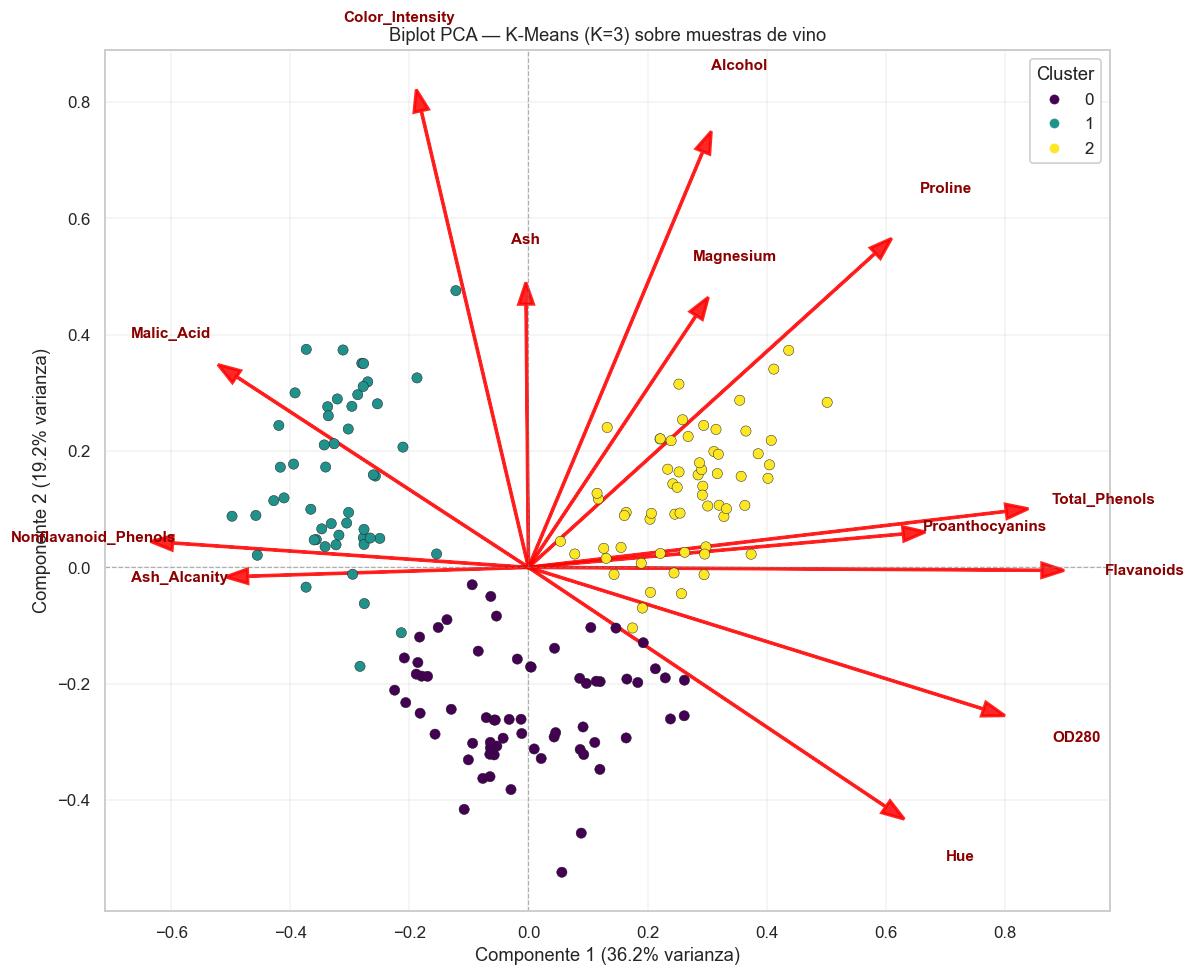

In [23]:
fig = km.plot_biplot(anotar=False, titulo=f"Biplot PCA — K-Means (K={K}) sobre muestras de vino")
plt.show()

**Proyección PCA y biplot:**
El PCA a dos componentes retiene el 55,4 % de la varianza (36,2 % + 19,2 %), mucho más que el 43,6 % del
dataset de clientes y partiendo de 13 variables en lugar de 5, lo que confirma que las correlaciones
detectadas antes generan una estructura latente que el PCA puede comprimir. El PC1 es un eje fenólico,
con cargas positivas altas en `Flavanoids` (0,42), `Total_Phenols` (0,39), `OD280` (0,38),
`Proanthocyanins` (0,31) y `Hue` (0,30), y negativas en `Nonflavanoid_Phenols`, `Malic_Acid` y
`Ash_Alcanity`; en el biplot las flechas de esas variables apuntan juntas hacia la derecha, reflejando el
bloque de correlaciones ya identificado. El PC2 es un eje de cuerpo y color, dominado por
`Color_Intensity` (0,53), `Alcohol` (0,48), `Proline` (0,36), `Ash` (0,32) y `Magnesium` (0,30).

La ubicación de los clusters en el plano es exactamente la que predicen sus perfiles: el cluster 1 queda
a la izquierda y arriba, con pocos flavonoides y mucho color; el cluster 2 a la derecha y arriba, con
fenoles y cuerpo altos; y el cluster 0 a la derecha y abajo, con fenoles medios pero poco cuerpo y color
pálido. Lo más importante es que los tres grupos ocupan regiones separadas con solapamiento mínimo, algo
que no se lograba en el dataset de clientes: es la evidencia visual de que aquí sí hay estructura real.

### Clustering jerárquico aglomerativo

In [24]:
cj = ClusteringJerarquico(X_scaled)
dist = cj.matriz_distancias(metric="euclidean")
print("Número de pares de distancias:", dist.shape[0])
print("Distancia mínima: %.3f | media: %.3f | máxima: %.3f" % (dist.min(), dist.mean(), dist.max()))

(178, 13)
Número de pares de distancias: 15753
Distancia mínima: 1.164 | media: 4.906 | máxima: 11.211


In [25]:
ward_res, average_res, single_res, complete_res = cj.calcular_agregaciones()
print("Matriz de enlaces de Ward (últimas 5 fusiones):")
print(np.round(ward_res[-5:], 2))

Matriz de enlaces de Ward (últimas 5 fusiones):
[[335.   345.    11.72  64.  ]
 [341.   347.    12.23  56.  ]
 [342.   349.    12.57  58.  ]
 [350.   352.    27.65 122.  ]
 [351.   353.    35.4  178.  ]]


**Matriz de distancias y de enlaces:**
Con 178 muestras se calculan 15 753 distancias por pares. La distancia euclídea media en el espacio
estandarizado de 13 dimensiones es de aproximadamente 4,8, con un mínimo cercano a 1,0 —dos vinos muy
parecidos— y un máximo superior a 10. La observación clave está en las últimas fusiones de Ward, cuyas
alturas finales son 12,57, 27,65 y 35,40: hay un salto abismal entre 12,57 y 27,65, más del doble, y
otro entre 27,65 y 35,40, lo que significa que las últimas uniones del árbol están juntando grupos
extremadamente diferentes entre sí, la firma inconfundible de clusters bien separados. En el dataset de
clientes las últimas alturas eran 32,43, 37,67, 40,25 y 48,29, con incrementos suaves y proporcionales
propios de un continuo; aquí el árbol indica con toda claridad dónde hay que cortarlo.

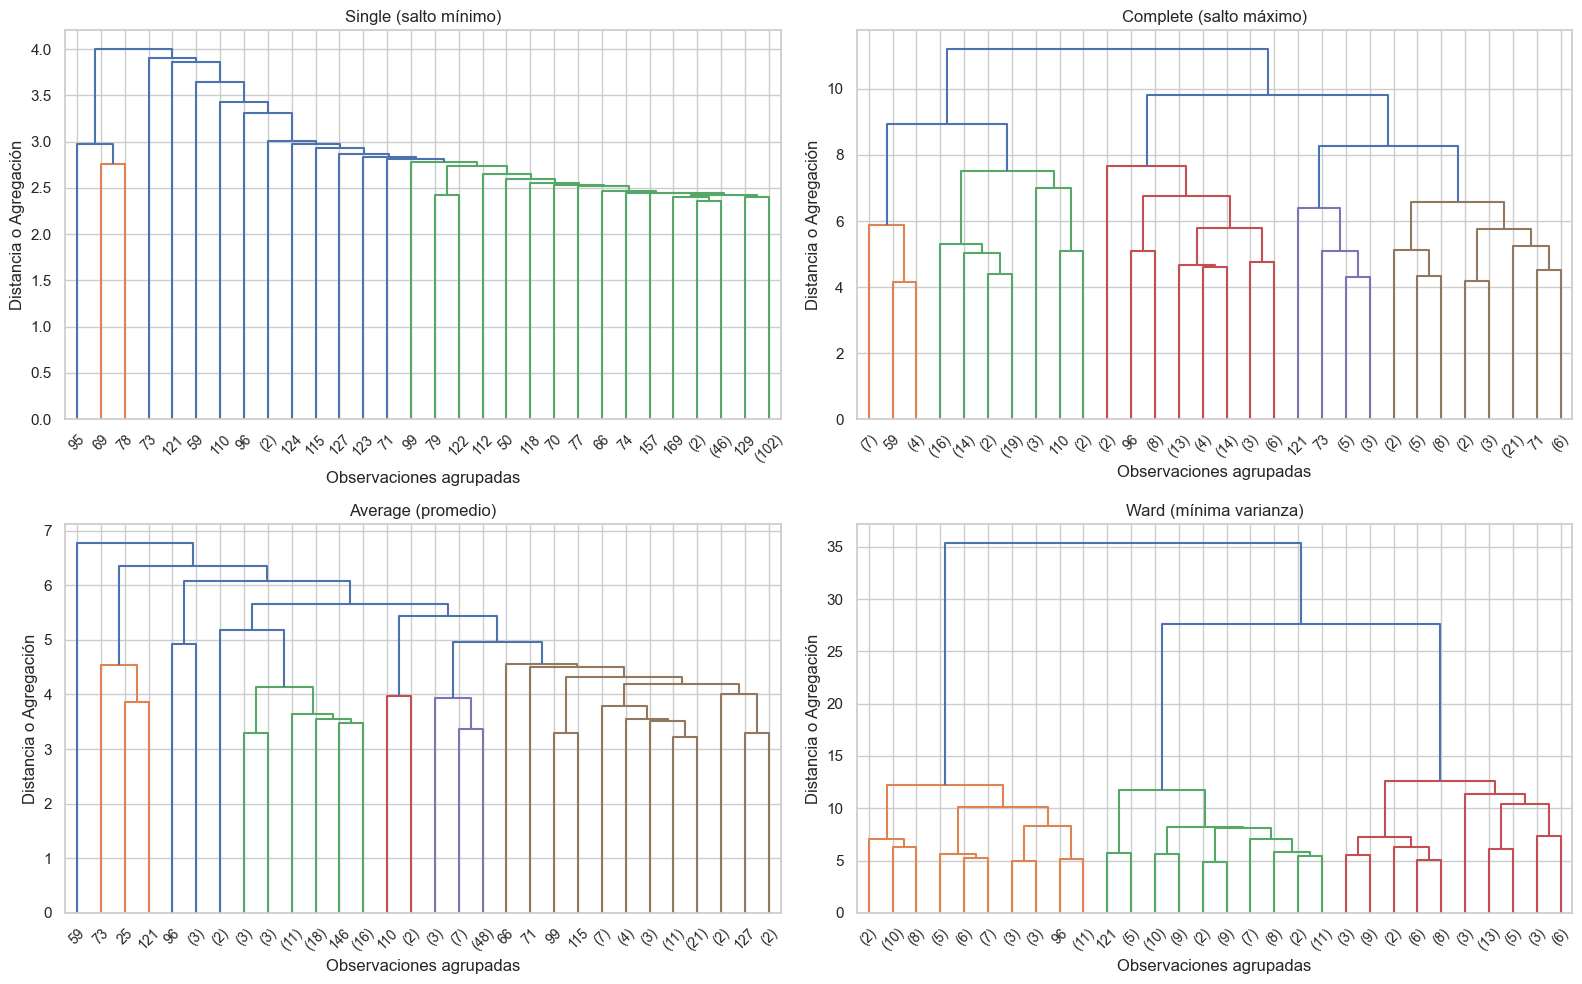

In [26]:
fig = cj.plot_dendrogramas_comparacion(figsize=(16, 10), truncate=30)
plt.show()

In [27]:
cj.correlacion_cophenetica()

,metodo,cophenetica
2,average,0.759
3,ward,0.662
1,complete,0.592
0,single,0.544


**Comparación de los métodos de vinculación:**
Las correlaciones cofenéticas son muy superiores a las del dataset de clientes, donde ninguna llegaba a
0,46: average alcanza 0,759, ward 0,662, complete 0,592 y single 0,544. Que hasta el peor método supere
al mejor del dataset anterior es una medida directa de cuánta más estructura jerárquica hay en los
vinos. Average es el que mejor preserva las distancias originales, pero su dendrograma muestra un único
bloque dominante del que se van desprendiendo muestras aisladas: una cofenética alta indica fidelidad
global a la matriz de distancias, no que los cortes del árbol produzcan grupos útiles. Ward alcanza un
valor sólido y sus dendrogramas muestran tres bloques muy claros separados por alturas grandes,
visualmente inconfundibles. Complete produce un árbol razonable pero con fusiones más desbalanceadas que
Ward, y single sigue mostrando efecto cadena, aunque menos marcado que en el dataset anterior.

Se usa Ward, porque combina una cofenética alta con la delimitación más nítida de los tres bloques y
porque su criterio de mínima varianza es el más comparable con K-Means.

In [28]:
# Alturas de corte del dendrograma de Ward
alturas_ward = np.sort(ward_res[:, 2])
print("Últimas 10 alturas de fusión (Ward):", np.round(alturas_ward[-10:], 2))

saltos = np.diff(alturas_ward[-10:])
print("\nSaltos entre alturas consecutivas:", np.round(saltos, 2))

cortes = {}
for k in [2, 3, 4, 5]:
    superior = alturas_ward[-(k - 1)]
    inferior = alturas_ward[-k]
    cortes[k] = round((superior + inferior) / 2, 1)
print("\nAlturas de corte para cada k:", cortes)

Últimas 10 alturas de fusión (Ward): [ 8.25  8.29 10.15 10.4  11.38 11.72 12.23 12.57 27.65 35.4 ]

Saltos entre alturas consecutivas: [ 0.04  1.86  0.24  0.98  0.35  0.51  0.34 15.08  7.75]

Alturas de corte para cada k: {2: np.float64(31.5), 3: np.float64(20.1), 4: np.float64(12.4), 5: np.float64(12.0)}


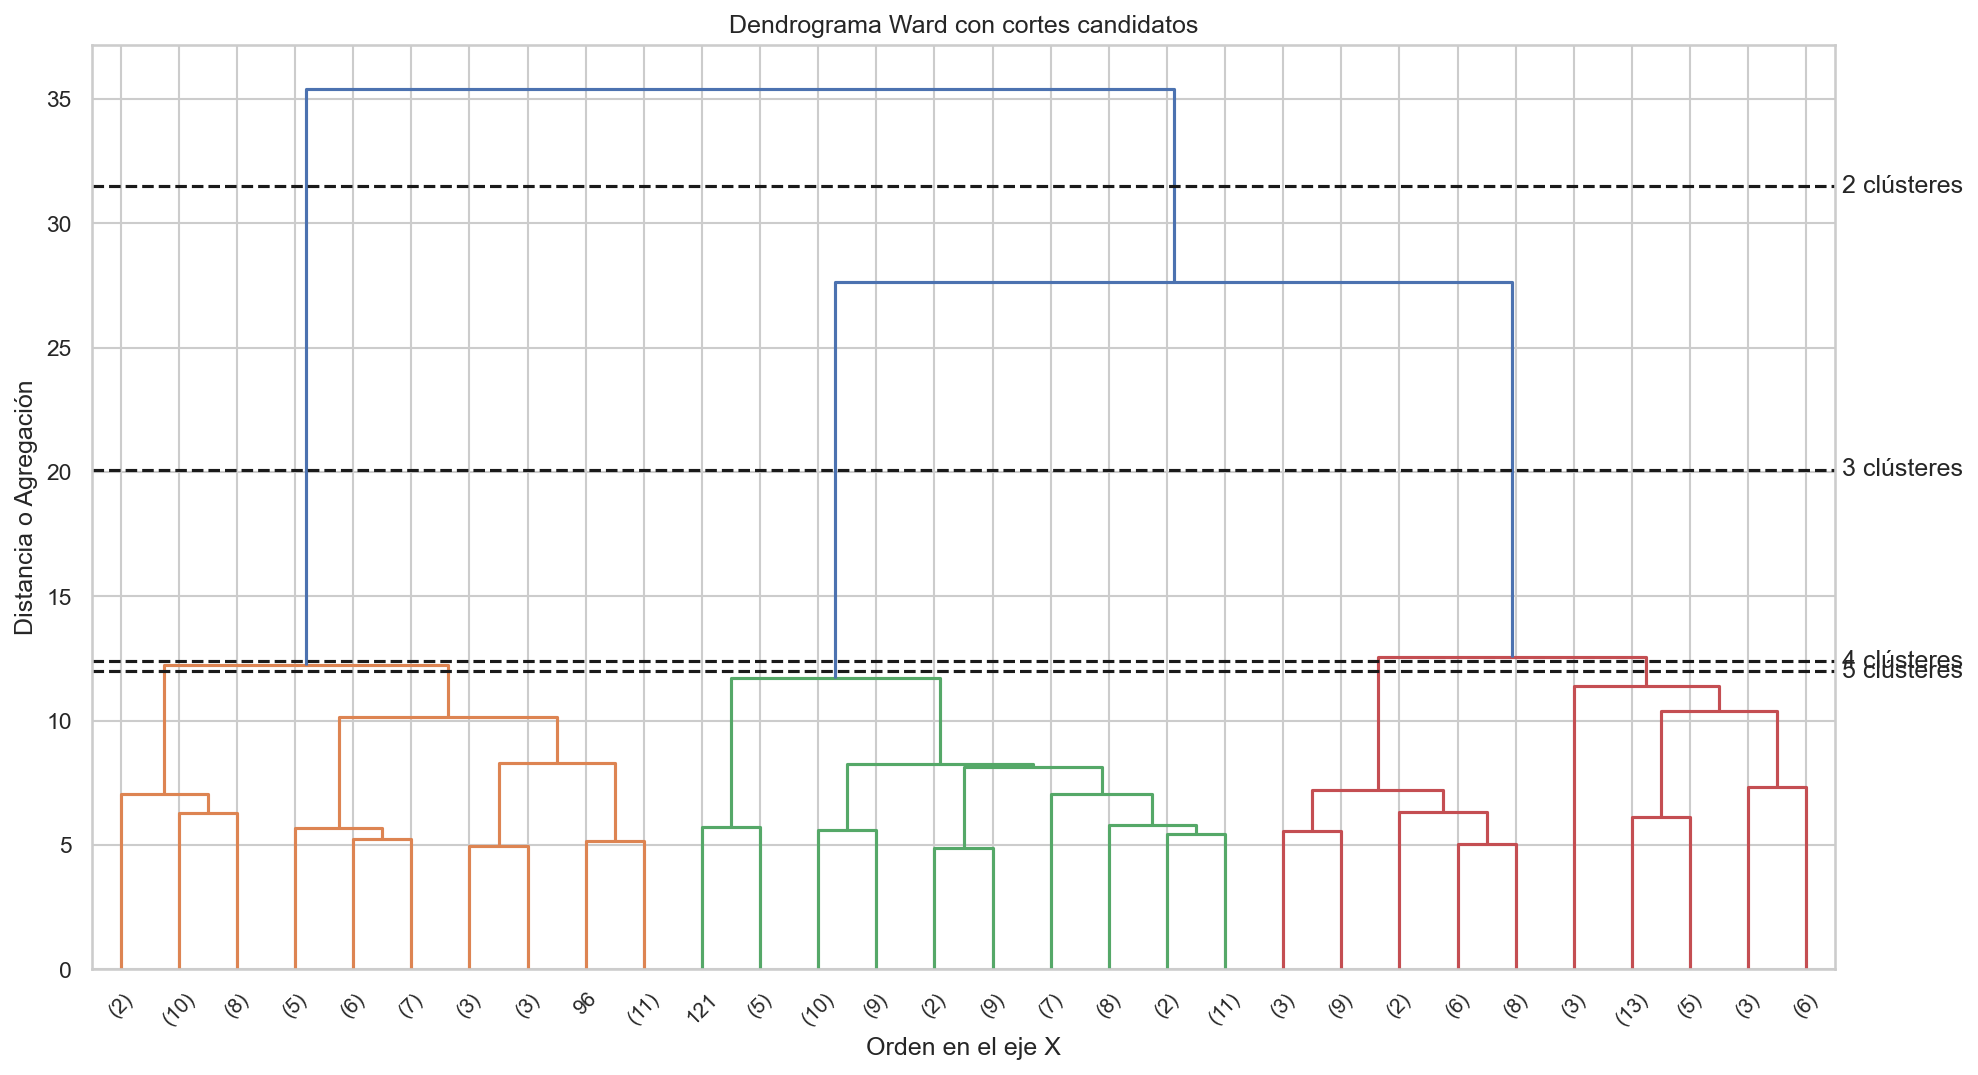

In [29]:
fig = cj.plot_dendrograma_corte(
    alturas=list(cortes.values()),
    etiquetas=[f"{k} clústeres" for k in cortes],
    figsize=(15, 8),
    truncate=30,
)
plt.show()

**Corte del dendrograma de Ward:**
El número de clusters es igual al número de ramas verticales que cruza cada línea horizontal. Las
alturas de corte, calculadas como el punto medio entre las dos fusiones que delimitan cada caso, son
31,5 para dos clusters, 20,1 para tres, 12,4 para cuatro y 12,0 para cinco. La regla del salto vertical
grande se aplica aquí con una claridad ejemplar: la serie de saltos entre alturas consecutivas termina
en 0,35 · 0,51 · 0,34 · 15,08 · 7,75, es decir que el salto de 12,57 a 27,65 es casi 45 veces mayor que
los saltos previos, y el siguiente, de 27,65 a 35,40, es de 7,75. Cortar en esa enorme banda vacía, con
la línea en 20,1, produce exactamente tres clusters, y visualmente la zona de corte es un espacio en
blanco imposible de confundir. El dendrograma valida K = 3 de forma independiente y contundente: el codo
de Jambú, la silueta y el mayor salto del árbol coinciden en el mismo valor.

In [30]:
grupos_cj = cj.obtener_grupos(k=K, method="ward", metric="euclidean")
print("Etiquetas de las primeras 50 muestras:")
print(grupos_cj[:50])
print("\nTamaño de cada cluster:")
print(pd.Series(grupos_cj).value_counts().sort_index())

Etiquetas de las primeras 50 muestras:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]

Tamaño de cada cluster:
0    56
1    64
2    58
Name: count, dtype: int64


In [31]:
centros_cj = cj.calcular_centros(k=K)
pd.DataFrame(centros_cj, columns=variables).round(2).rename_axis("cluster").T

cluster,0,1,2
Alcohol,0.08,0.83,-0.98
Malic_Acid,0.75,-0.33,-0.36
Ash,0.17,0.35,-0.55
Ash_Alcanity,0.45,-0.59,0.21
Magnesium,0.01,0.45,-0.50
Total_Phenols,-0.96,0.89,-0.05
Flavanoids,-1.19,0.98,0.06
Nonflavanoid_Phenols,0.71,-0.57,-0.05
Proanthocyanins,-0.81,0.56,0.17
Color_Intensity,0.78,0.17,-0.94


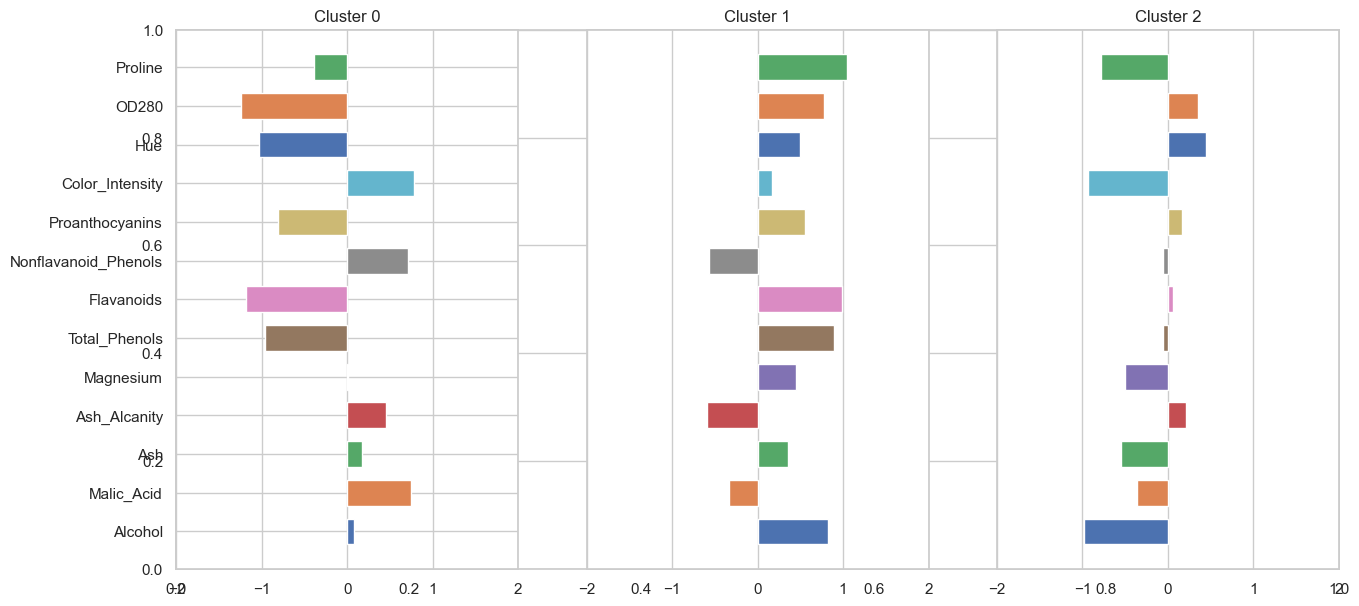

In [32]:
fig = cj.plot_barras_centros(figsize=(15, 7))
plt.show()

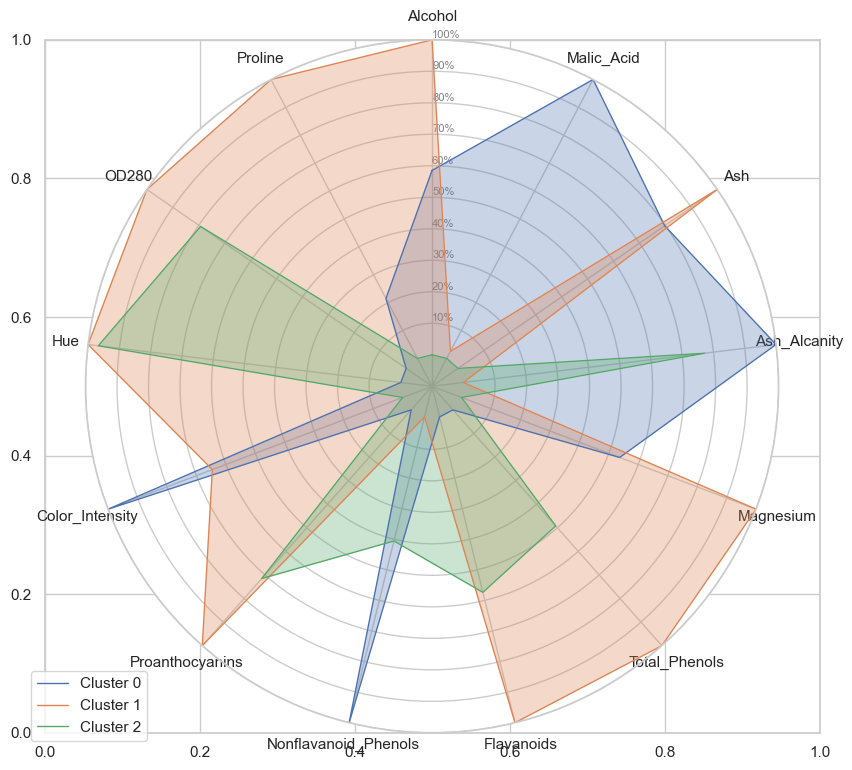

In [33]:
fig = cj.plot_radar_centros(figsize=(10, 9))
plt.show()

In [34]:
perfil_cj = cj.tabla_perfiles(datos_originales=df)
perfil_cj.T

cluster,0,1,2
n,56.00,64.00,58.00
Alcohol,13.06,13.67,12.20
Malic_Acid,3.17,1.97,1.94
Ash,2.41,2.46,2.22
Ash_Alcanity,21.00,17.53,20.21
Magnesium,99.86,106.16,92.55
Total_Phenols,1.69,2.85,2.26
Flavanoids,0.85,3.01,2.09
Nonflavanoid_Phenols,0.45,0.29,0.36
Proanthocyanins,1.13,1.91,1.69


**Perfil de los clusters jerárquicos (Ward, k = 3):**
Ward encuentra grupos de tamaños 56, 64 y 58, muy equilibrados, y sus perfiles son prácticamente los
mismos que los de K-Means, solo con las etiquetas permutadas: su cluster 0 corresponde a los vinos
tánicos y ácidos (`Flavanoids` 0,85, `Color_Intensity` 6,85, `Hue` 0,72, `Malic_Acid` 3,17), su
cluster 1 a los estructurados (`Alcohol` 13,67, `Flavanoids` 3,01, `Proline` 1 076) y su cluster 2 a los
ligeros (`Alcohol` 12,20, `Color_Intensity` 2,90, `Proline` 501). Las medias por variable coinciden con
una precisión notable: para el grupo estructurado K-Means da `Alcohol` 13,68, `Flavanoids` 3,00 y
`Proline` 1 100, y Ward da 13,67, 3,01 y 1 076, diferencias de decimales.

Este es el contraste más fuerte con el dataset de clientes, donde los dos algoritmos producían perfiles
contradictorios: allí el grupo de alto gasto era joven según K-Means y mayor según Ward. Cuando los
grupos son reales, dos algoritmos con lógicas distintas —optimización iterativa de centroides frente a
fusión jerárquica irreversible— convergen a la misma solución; cuando no lo son, cada uno inventa su
propia partición.

---
## e) Análisis y conclusiones visuales

In [35]:
tabla_cruzada = pd.crosstab(
    pd.Series(etiquetas_km, name="K-Means"),
    pd.Series(grupos_cj, name="Ward (jerárquico)"),
)
tabla_cruzada

Ward (jerárquico),0,1,2
K-Means,,,
0,5,3,57
1,51,0,0
2,0,61,1


In [36]:
ari = adjusted_rand_score(grupos_cj, etiquetas_km)
sil_km = silhouette_score(X, etiquetas_km)
sil_cj = silhouette_score(X, grupos_cj)

pd.DataFrame({
    "métrica": ["Silueta media", "Nº de clusters", "Cluster más pequeño", "Cluster más grande"],
    "K-Means": [round(sil_km, 4), K, int(np.bincount(etiquetas_km).min()), int(np.bincount(etiquetas_km).max())],
    "Ward": [round(sil_cj, 4), K, int(np.bincount(grupos_cj).min()), int(np.bincount(grupos_cj).max())],
})

,métrica,K-Means,Ward
0,Silueta media,0.2849,0.2774
1,Nº de clusters,3.0000,3.0000
2,Cluster más pequeño,51.0000,56.0000
3,Cluster más grande,65.0000,64.0000


In [37]:
print(f"Índice de Rand ajustado (ARI) entre K-Means y Ward: {ari:.3f}")
n_coincidencias = tabla_cruzada.values.max(axis=1).sum()
print(f"Muestras asignadas al grupo homólogo: {n_coincidencias} de {len(df)} ({n_coincidencias / len(df) * 100:.1f} %)")

Índice de Rand ajustado (ARI) entre K-Means y Ward: 0.853
Muestras asignadas al grupo homólogo: 169 de 178 (94.9 %)


**Grado de acuerdo entre los algoritmos:**
El ARI es de 0,853, frente a los 0,243 del dataset de clientes: los dos algoritmos han encontrado, en
esencia, la misma partición. La tabla cruzada lo muestra con claridad, porque cada fila de K-Means se
concentra casi por completo en una única columna de Ward: los ligeros coinciden en 57 de 65 muestras,
los tánicos en 51 de 51 —coincidencia perfecta— y los estructurados en 61 de 62, para un total de 169 de
178 muestras (94,9 %) con la misma asignación. Los nueve desacuerdos se concentran en el grupo de vinos
ligeros, que es el de frontera más difusa. En calidad las dos siluetas son casi idénticas, 0,2849 en
K-Means frente a 0,2774 en Ward, cuando en el dataset de clientes la brecha era siete veces mayor:
cuando los grupos son reales la elección del algoritmo pesa poco, y cuando no lo son cada algoritmo
impone su propio sesgo geométrico. Ambos algoritmos son válidos para este dataset y sus resultados son
intercambiables, con la ventaja adicional de que Ward ofrece el dendrograma como herramienta de
validación.

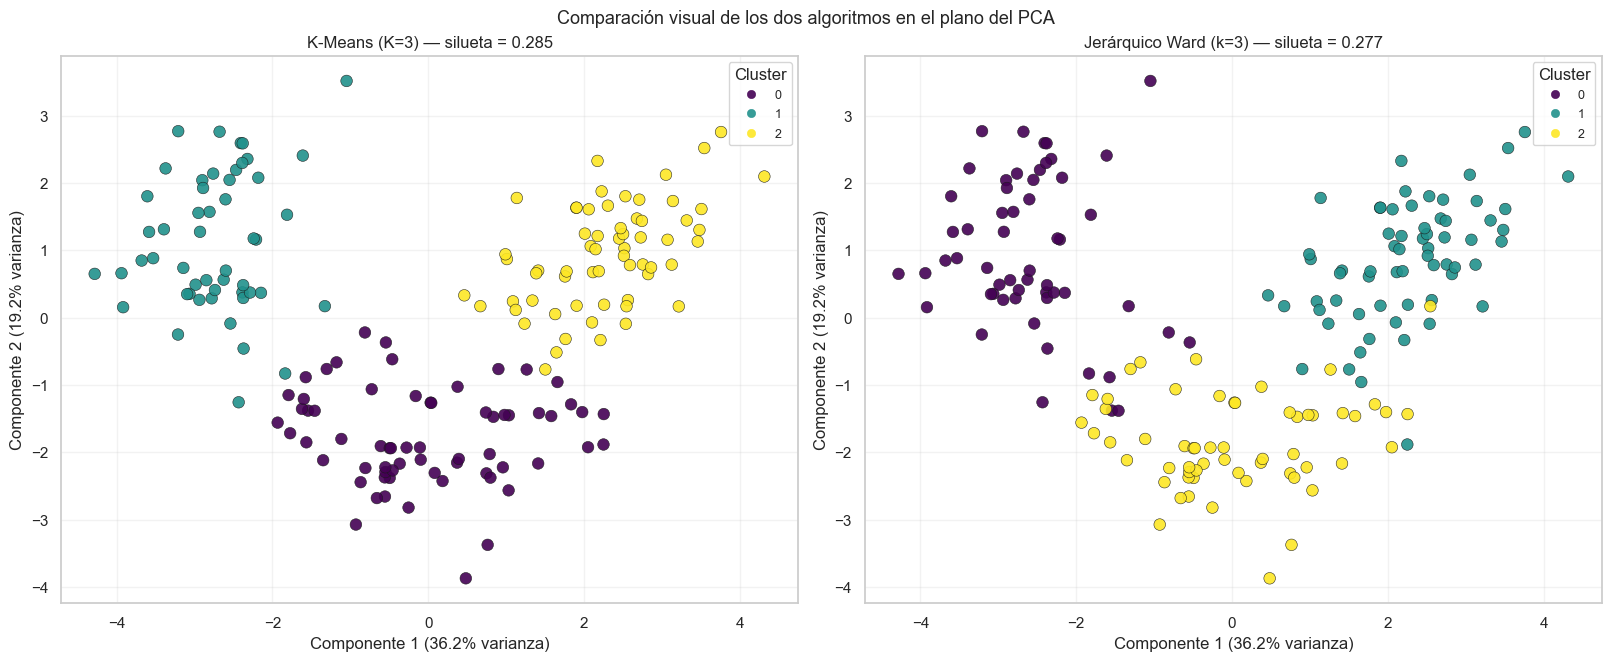

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), constrained_layout=True)
var_exp = km.pca.explained_variance_ratio_ * 100

for ax, (labels, titulo, sil) in zip(
    axes,
    [(etiquetas_km, f"K-Means (K={K})", sil_km), (grupos_cj, f"Jerárquico Ward (k={K})", sil_cj)],
):
    sc = ax.scatter(componentes[:, 0], componentes[:, 1], c=labels, cmap="viridis",
                    s=70, edgecolor="k", linewidth=0.4, alpha=0.9)
    ax.set_xlabel(f"Componente 1 ({var_exp[0]:.1f}% varianza)")
    ax.set_ylabel(f"Componente 2 ({var_exp[1]:.1f}% varianza)")
    ax.set_title(f"{titulo} — silueta = {sil:.3f}")
    ax.legend(*sc.legend_elements(), title="Cluster", loc="best", fontsize=9)
    ax.grid(alpha=0.25)

fig.suptitle("Comparación visual de los dos algoritmos en el plano del PCA", fontsize=13)
plt.show()

Muestras en desacuerdo: 9 de 178


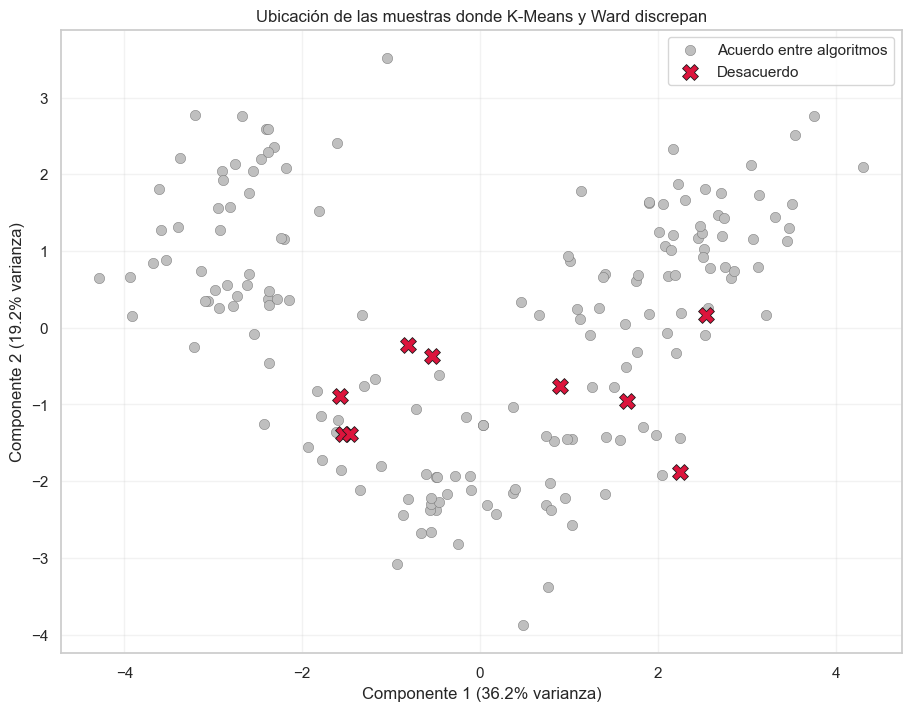

In [39]:
# Muestras donde los dos algoritmos discrepan
mapeo = tabla_cruzada.idxmax(axis=1).to_dict()  # cluster K-Means → cluster Ward homólogo
km_traducido = np.array([mapeo[c] for c in etiquetas_km])
discrepan = km_traducido != grupos_cj
print(f"Muestras en desacuerdo: {int(discrepan.sum())} de {len(df)}")

fig, ax = plt.subplots(figsize=(9, 7), constrained_layout=True)
ax.scatter(componentes[~discrepan, 0], componentes[~discrepan, 1], c="0.75",
           s=55, edgecolor="0.4", linewidth=0.3, label="Acuerdo entre algoritmos")
ax.scatter(componentes[discrepan, 0], componentes[discrepan, 1], c="crimson",
           s=130, edgecolor="k", linewidth=0.6, marker="X", label="Desacuerdo", zorder=3)
ax.set_xlabel(f"Componente 1 ({var_exp[0]:.1f}% varianza)")
ax.set_ylabel(f"Componente 2 ({var_exp[1]:.1f}% varianza)")
ax.set_title("Ubicación de las muestras donde K-Means y Ward discrepan")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

**Comparación visual y localización de los desacuerdos:**
Los dos paneles son casi indistinguibles —la misma nube, los mismos tres grupos en las mismas
posiciones, apenas con un cambio de color por la permutación de etiquetas—, en contraste con el dataset
de clientes, donde mostraban particiones visiblemente distintas del mismo espacio. El gráfico de
desacuerdos es la pieza más informativa: las nueve muestras en conflicto se ubican todas en las zonas
fronterizas entre grupos y ninguna cae en el núcleo de un cluster. Los dos algoritmos coinciden
plenamente en el núcleo de cada grupo y solo difieren en cómo asignan las muestras ambiguas de las
fronteras, que es el comportamiento esperado cuando existen tres poblaciones reales con cierto grado de
transición química entre ellas, algo perfectamente plausible entre cultivares cultivados en la misma
región.

**Conclusión:**
El dataset llegó completamente limpio, con 0 nulos y 0 duplicados, así que el preprocesamiento se limitó
a documentar los atípicos —21 celdas por la regla del IQR, ninguna variable con más del 2,2 %— y a
decidir conservarlos, porque en datos de laboratorio los valores extremos son mediciones válidas y son
justamente la señal que permite distinguir los cultivares. La estandarización era crítica: `Proline`
frente a `Nonflavanoid_Phenols` supone una diferencia de escala de tres órdenes de magnitud, y sin
z-score el clustering habría sido un simple ordenamiento por prolina.

K = 3 quedó confirmado por triple validación convergente: el codo de Jambú, con 28,2 % y 23,1 % de
reducción en los dos primeros pasos frente a solo 5,2 % en el tercero; la silueta, con su máximo global
en k=3 y descenso posterior; y el dendrograma de Ward, cuyo mayor salto de altura, de 12,57 a 27,65,
corresponde exactamente al corte en tres clusters. El resultado coincide además con el conocimiento de
dominio, porque el dataset UCI Wine original proviene de tres cultivares italianos y los tamaños
obtenidos son compatibles con la distribución real de las clases. La silueta de 0,285 sigue siendo
moderada en términos absolutos por efecto de la dimensionalidad, de modo que la estructura es real pero
los grupos tienen fronteras de transición y no separación tajante. Conviene señalar también que la
correlación cofenética no basta para elegir el método de vinculación: average obtuvo el valor más alto y
sin embargo su árbol desprende muestras aisladas de un bloque dominante en lugar de delimitar los tres
grupos, mientras que Ward, con cofenética inferior, produce la partición correcta.

La comparación entre algoritmos es el resultado central de la tarea: K-Means y Ward convergen en 169 de
178 muestras (94,9 %), con medias de grupo que coinciden hasta los decimales y siluetas casi idénticas, y
los nueve desacuerdos están todos en las fronteras. Frente al ARI de 0,243 y los perfiles
contradictorios del dataset de clientes, la lección metodológica es que la convergencia entre dos
algoritmos con lógicas distintas es en sí misma una prueba de la existencia de estructura real, y su
divergencia una señal de alarma: un criterio de validación que ninguna métrica individual proporciona.
Los tres perfiles obtenidos —ligeros, tánicos y ácidos, y estructurados— tienen interpretación enológica
coherente, y ninguna variable individual los separa por sí sola, lo que justifica plenamente el enfoque
multivariante. Un modelo de este tipo permitiría clasificar una muestra de vino desconocida en uno de
los tres perfiles a partir de su analítica de laboratorio, sin conocer su cultivar de origen.